“This project performs Exploratory Data Analysis (EDA) on the MovieLens dataset to understand user rating behavior, movie popularity, and genre preferences.”

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load files
ratings = pd.read_csv('ratings.csv')
movies = pd.read_csv('movies.csv')

# Quick look
print("Ratings shape:", ratings.shape)
print("Movies shape:", movies.shape)
print("\n", ratings.head())
print("\n", movies.head())

Ratings shape: (100004, 4)
Movies shape: (9125, 3)

    userId  movieId  rating   timestamp
0       1       31     2.5  1260759144
1       1     1029     3.0  1260759179
2       1     1061     3.0  1260759182
3       1     1129     2.0  1260759185
4       1     1172     4.0  1260759205

    movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


In [2]:
# Check structure
print("=== RATINGS INFO ===")
print(ratings.info())

print("\n=== MOVIES INFO ===")
print(movies.info())

# Check for nulls
print("\n=== NULL VALUES ===")
print("Ratings nulls:\n", ratings.isnull().sum())
print("Movies nulls:\n", movies.isnull().sum())

# Check duplicates
print("\n=== DUPLICATES ===")
print("Ratings duplicates:", ratings.duplicated().sum())
print("Movies duplicates:", movies.duplicated().sum())

# Basic stats
print("\n=== RATING STATS ===")
print(ratings['rating'].describe())


=== RATINGS INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100004 entries, 0 to 100003
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100004 non-null  int64  
 1   movieId    100004 non-null  int64  
 2   rating     100004 non-null  float64
 3   timestamp  100004 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
None

=== MOVIES INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9125 entries, 0 to 9124
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9125 non-null   int64 
 1   title    9125 non-null   object
 2   genres   9125 non-null   object
dtypes: int64(1), object(2)
memory usage: 214.0+ KB
None

=== NULL VALUES ===
Ratings nulls:
 userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
Movies nulls:
 movieId    0
title      0
genres     0
dtype: int64

=== DUPLICATES ===
Ra

In [3]:
# 1. Convert timestamp to readable date
ratings['date'] = pd.to_datetime(ratings['timestamp'], unit='s')
ratings['year'] = ratings['date'].dt.year
ratings['month'] = ratings['date'].dt.month

# 2. Extract year from movie title  (e.g. "Toy Story (1995)" → 1995)
movies['release_year'] = movies['title'].str.extract(r'\((\d{4})\)')
movies['release_year'] = pd.to_numeric(movies['release_year'], errors='coerce')

# 3. Clean title (remove year from title)
movies['clean_title'] = movies['title'].str.replace(r'\s*\(\d{4}\)', '', regex=True)

# 4. Merge ratings + movies into one dataframe
df = ratings.merge(movies, on='movieId')

# Check final dataframe
print(df.shape)
print(df.head())
print(df.columns.tolist())


(100004, 11)
   userId  movieId  rating   timestamp                date  year  month  \
0       1       31     2.5  1260759144 2009-12-14 02:52:24  2009     12   
1       1     1029     3.0  1260759179 2009-12-14 02:52:59  2009     12   
2       1     1061     3.0  1260759182 2009-12-14 02:53:02  2009     12   
3       1     1129     2.0  1260759185 2009-12-14 02:53:05  2009     12   
4       1     1172     4.0  1260759205 2009-12-14 02:53:25  2009     12   

                                            title  \
0                          Dangerous Minds (1995)   
1                                    Dumbo (1941)   
2                                 Sleepers (1996)   
3                     Escape from New York (1981)   
4  Cinema Paradiso (Nuovo cinema Paradiso) (1989)   

                             genres  release_year  \
0                             Drama        1995.0   
1  Animation|Children|Drama|Musical        1941.0   
2                          Thriller        1996.0   
3  Ac

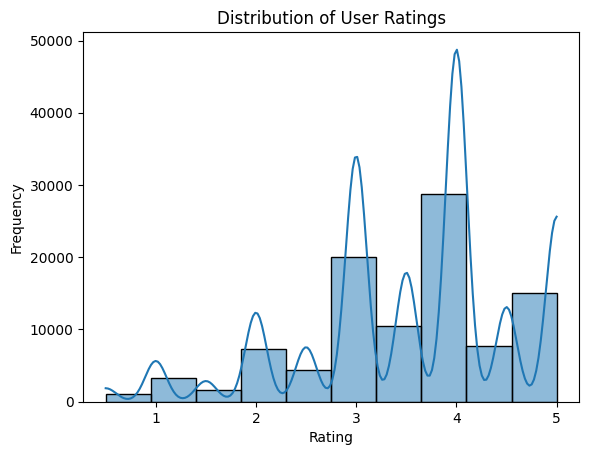

In [4]:
sns.histplot(df['rating'], bins=10, kde=True)
plt.title("Distribution of User Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

In [5]:
df['rating'].mean()

np.float64(3.543608255669773)

In [8]:
df.isnull().sum()

userId          0
movieId         0
rating          0
timestamp       0
date            0
year            0
month           0
title           0
genres          0
release_year    0
clean_title     0
dtype: int64

In [7]:
df = df.dropna(subset=['release_year'])

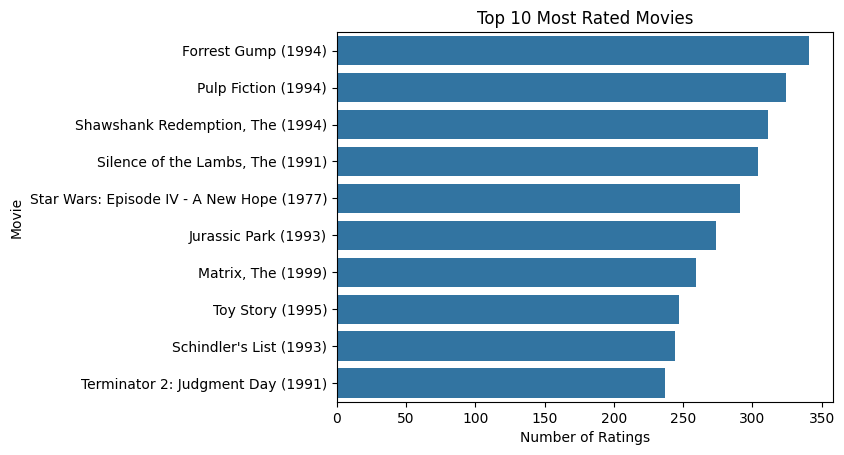

In [9]:
top_movies = df['title'].value_counts().head(10)

sns.barplot(x=top_movies.values, y=top_movies.index)
plt.title("Top 10 Most Rated Movies")
plt.xlabel("Number of Ratings")
plt.ylabel("Movie")
plt.show()

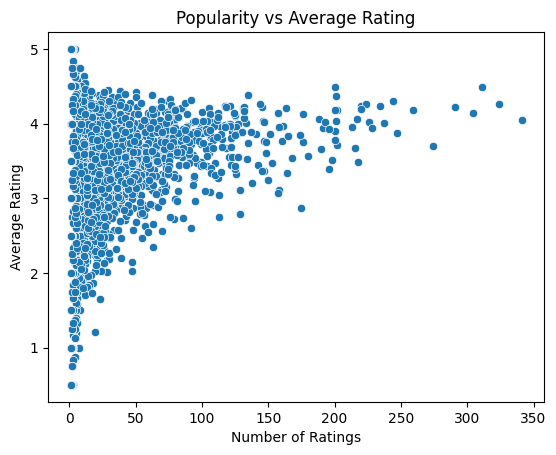

In [10]:
movie_stats = df.groupby('title').agg({
    'rating': ['mean', 'count']
})

movie_stats.columns = ['avg_rating', 'num_ratings']
movie_stats = movie_stats.reset_index()

sns.scatterplot(data=movie_stats, x='num_ratings', y='avg_rating')
plt.title("Popularity vs Average Rating")
plt.xlabel("Number of Ratings")
plt.ylabel("Average Rating")
plt.show()

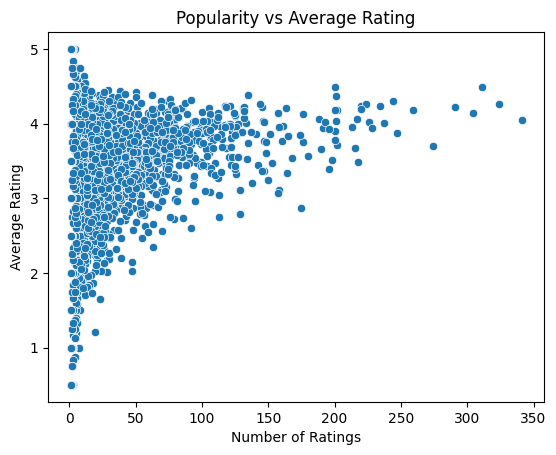

In [11]:
movie_stats = df.groupby('title').agg({
    'rating': ['mean', 'count']
})

movie_stats.columns = ['avg_rating', 'num_ratings']
movie_stats = movie_stats.reset_index()

sns.scatterplot(data=movie_stats, x='num_ratings', y='avg_rating')
plt.title("Popularity vs Average Rating")
plt.xlabel("Number of Ratings")
plt.ylabel("Average Rating")
plt.show()

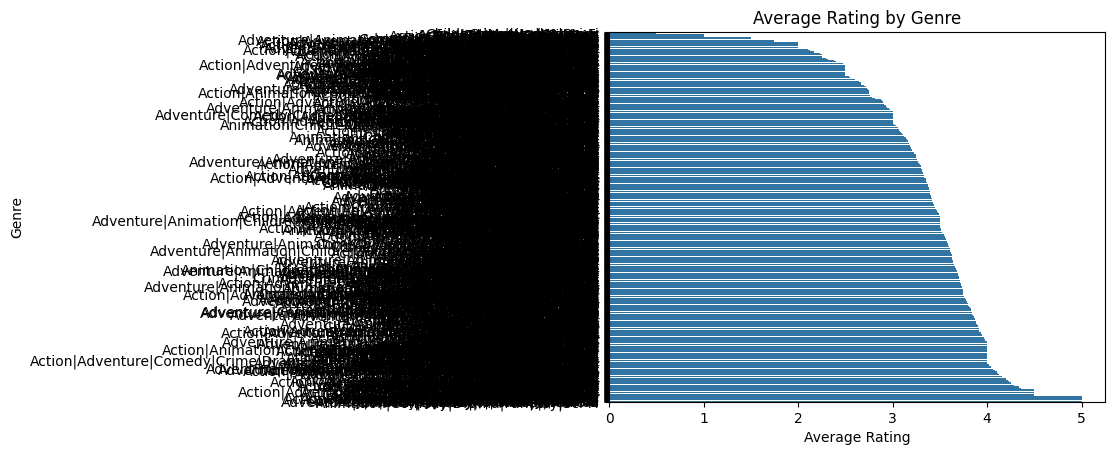

In [12]:
genre_df = df.explode('genres')

genre_ratings = genre_df.groupby('genres')['rating'].mean().sort_values()

sns.barplot(x=genre_ratings.values, y=genre_ratings.index)
plt.title("Average Rating by Genre")
plt.xlabel("Average Rating")
plt.ylabel("Genre")
plt.show()

In [13]:
df['genres'] = df['genres'].str.split('|')


In [14]:
genre_df = df.explode('genres')

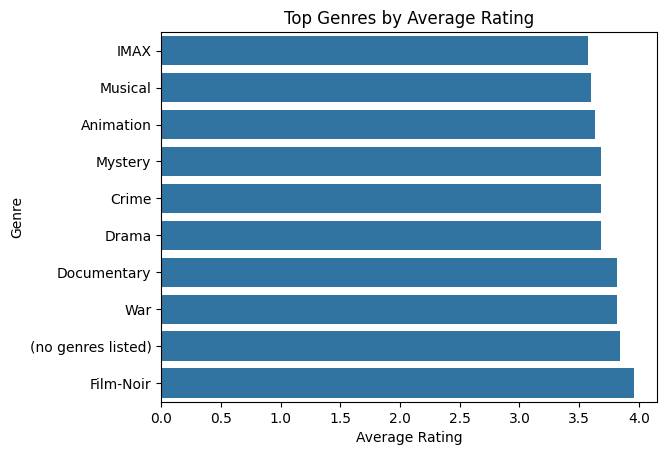

In [15]:
genre_ratings = genre_df.groupby('genres')['rating'].mean().sort_values()

# Take top 10 for clarity
genre_ratings = genre_ratings.tail(10)

sns.barplot(x=genre_ratings.values, y=genre_ratings.index)
plt.title("Top Genres by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Genre")
plt.show()

In [16]:
genre_df = genre_df[genre_df['genres'] != '(no genres listed)']

In [18]:
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')

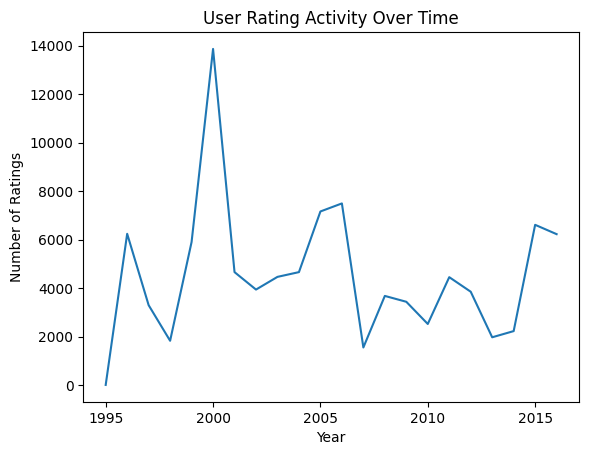

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure df exists (run upstream preprocessing cells first)
if 'df' not in globals():
	ratings = pd.read_csv('ratings.csv')
	movies = pd.read_csv('movies.csv')
	movies['release_year'] = movies['title'].str.extract(r'\((\d{4})\)')
	movies['release_year'] = pd.to_numeric(movies['release_year'], errors='coerce')
	movies['clean_title'] = movies['title'].str.replace(r'\s*\(\d{4}\)', '', regex=True)
	df = ratings.merge(movies, on='movieId')
	df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')

df['year_rated'] = df['timestamp'].dt.year

ratings_trend = df.groupby('year_rated').size()

ratings_trend.plot()
plt.title("User Rating Activity Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Ratings")
plt.show()

This analysis highlights patterns in user behavior and movie characteristics. 
The findings can support recommendation systems by identifying popular, 
highly-rated, and underexplored movies.